# Árbol de Decisión — Predicción de Riesgo de Infarto Cardíaco
Notebook para **Google Colab**. Sube tu archivo `data.csv` con el botón de la celda 2 y ejecuta todo en orden.

Dataset: variables clínicas (edad, sexo, tipo de dolor de pecho, presión arterial, colesterol, etc.) y variable objetivo `num` (0 = sin riesgo, 1 = con riesgo de infarto).


## Bloque 1 — Instalar e importar librerías

In [1]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Subir archivos desde Google Colab
from google.colab import files
import io

print("Librerías cargadas correctamente")


Librerías cargadas correctamente


## Bloque 2 — Subir el dataset desde tu equipo
Ejecuta esta celda y aparecerá un botón **"Choose Files"**: selecciona tu archivo `data.csv`.

In [4]:
import os

nombre_archivo = "data.csv"

if os.path.exists(nombre_archivo):
    print(f"Encontrado '{nombre_archivo}' ya subido al entorno. Cargando...")
else:
    print("No se encontró 'data.csv' en el entorno. Abriendo el botón de carga clásico...")
    try:
        uploaded = files.upload()
        nombre_archivo = list(uploaded.keys())[0]
    except Exception as e:
        print("El botón de carga falló:", e)
        print("Sube el archivo manualmente con el ícono de carpeta 📁 del panel izquierdo y vuelve a ejecutar esta celda.")
        raise

df = pd.read_csv(nombre_archivo)

# Limpiar espacios en los nombres de columnas (el CSV original trae espacios extra)
df.columns = [c.strip() for c in df.columns]

print("Forma del dataset:", df.shape)
df.head()


Encontrado 'data.csv' ya subido al entorno. Cargando...
Forma del dataset: (294, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


## Bloque 3 — Exploración inicial de los datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB

Distribución de la variable objetivo (num):
num
0    188
1    106
Name: count, dtype: int64


/tmp/ipykernel_577/1376756439.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="num", data=df, palette=["#2980b9", "#c0392b"])


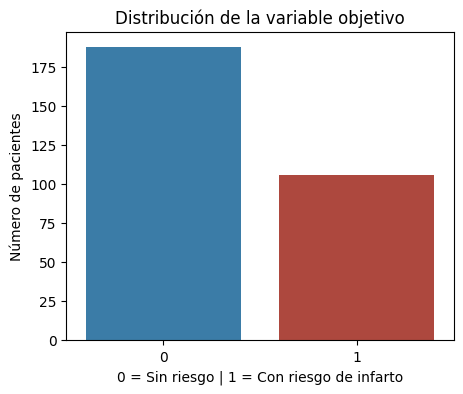

In [5]:
df.info()

print("\nDistribución de la variable objetivo (num):")
print(df["num"].value_counts())

plt.figure(figsize=(5, 4))
sns.countplot(x="num", data=df, palette=["#2980b9", "#c0392b"])
plt.title("Distribución de la variable objetivo")
plt.xlabel("0 = Sin riesgo | 1 = Con riesgo de infarto")
plt.ylabel("Número de pacientes")
plt.show()


## Bloque 4 — Limpieza y preprocesamiento de los datos
Este dataset marca los valores faltantes con el símbolo `?` en vez de dejarlos vacíos, así que hay que convertirlos primero.
Las columnas `slope`, `ca` y `thal` tienen muchísimos valores faltantes (más del 60%), así que se descartan por no aportar información confiable.

In [6]:
# Reemplazar "?" por NaN
df = df.replace("?", np.nan)

# Revisar el porcentaje de valores faltantes por columna
print("Porcentaje de valores faltantes por columna:")
print((df.isnull().mean() * 100).round(1).sort_values(ascending=False))

# Eliminar columnas con demasiados valores faltantes
df = df.drop(columns=["slope", "ca", "thal"])

# Convertir todas las columnas restantes a numéricas
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Imputar los pocos valores faltantes restantes con la mediana de cada columna
df = df.fillna(df.median(numeric_only=True))

print("\nForma final del dataset:", df.shape)
print("Valores nulos restantes:", df.isnull().sum().sum())


Porcentaje de valores faltantes por columna:
ca          99.0
thal        90.5
slope       64.6
chol         7.8
fbs          2.7
trestbps     0.3
thalach      0.3
exang        0.3
restecg      0.3
age          0.0
cp           0.0
sex          0.0
oldpeak      0.0
num          0.0
dtype: float64

Forma final del dataset: (294, 11)
Valores nulos restantes: 0


## Bloque 5 — Separar variables y dividir en entrenamiento / validación / prueba

In [7]:
X = df.drop(columns=["num"])
y = df["num"]

feature_names = list(X.columns)

# 70% entrenamiento, 15% validación, 15% prueba
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print("Entrenamiento:", X_train.shape)
print("Validación   :", X_val.shape)
print("Prueba       :", X_test.shape)


Entrenamiento: (205, 10)
Validación   : (44, 10)
Prueba       : (45, 10)


## Bloque 6 — Entrenar el árbol de decisión (con ajuste de hiperparámetros)
Se usa `GridSearchCV` para probar distintas combinaciones de profundidad máxima, mínimo de muestras por división y criterio de separación, seleccionando la combinación que mejor generaliza en el conjunto de validación.

In [8]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini", "entropy"],
}

arbol_base = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    arbol_base,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)

# Se combina train + validación para la búsqueda con validación cruzada
grid.fit(pd.concat([X_train, X_val]), pd.concat([y_train, y_val]))

print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)

modelo = grid.best_estimator_


Mejores hiperparámetros encontrados:
{'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 2}


## Bloque 7 — Evaluar el modelo sobre el conjunto de prueba

In [9]:
y_pred = modelo.predict(X_test)
y_proba = modelo.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("================================")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precisión: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-score : {f1*100:.2f}%")
print(f"AUC-ROC  : {auc:.3f}")
print("================================")

print("\nReporte de clasificación completo:\n")
print(classification_report(y_test, y_pred, target_names=["Sin riesgo", "Con riesgo"]))


Accuracy : 77.78%
Precisión: 66.67%
Recall   : 75.00%
F1-score : 70.59%
AUC-ROC  : 0.873

Reporte de clasificación completo:

              precision    recall  f1-score   support

  Sin riesgo       0.85      0.79      0.82        29
  Con riesgo       0.67      0.75      0.71        16

    accuracy                           0.78        45
   macro avg       0.76      0.77      0.76        45
weighted avg       0.79      0.78      0.78        45



## Bloque 8 — Matriz de confusión y curva ROC

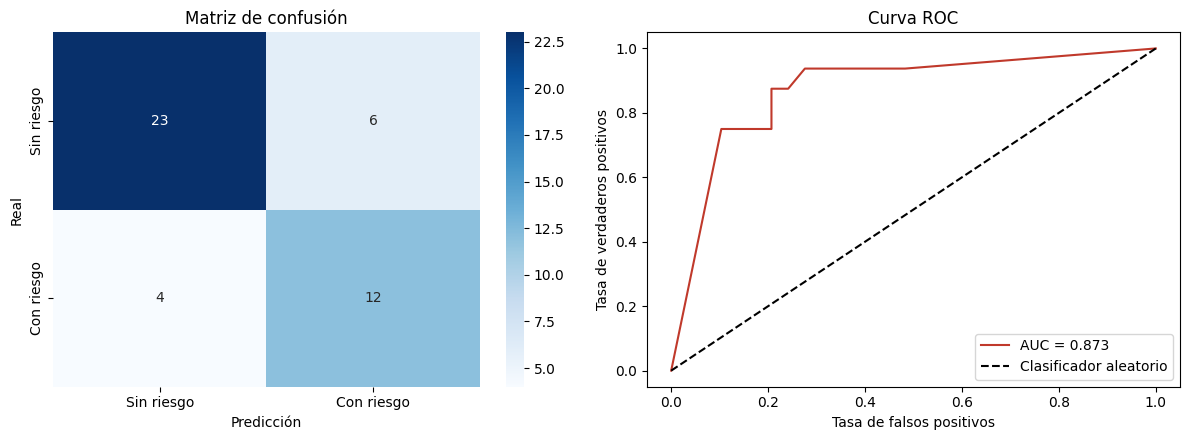

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Sin riesgo", "Con riesgo"],
    yticklabels=["Sin riesgo", "Con riesgo"],
    ax=axes[0],
)
axes[0].set_title("Matriz de confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f"AUC = {auc:.3f}", color="#c0392b")
axes[1].plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
axes[1].set_title("Curva ROC")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].legend()

plt.tight_layout()
plt.show()


## Bloque 9 — Visualizar el árbol de decisión e importancia de variables

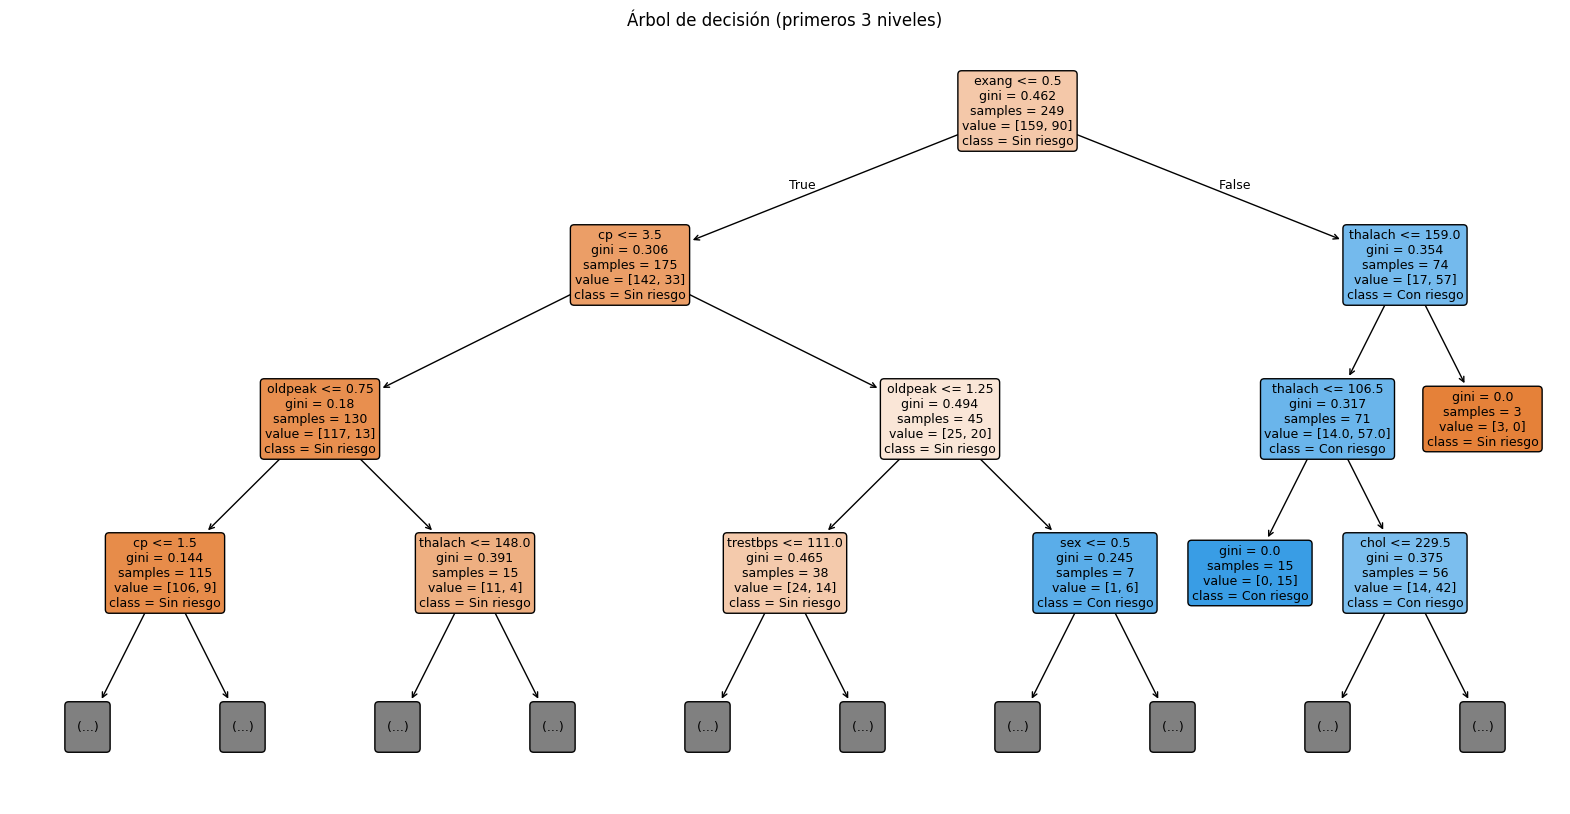

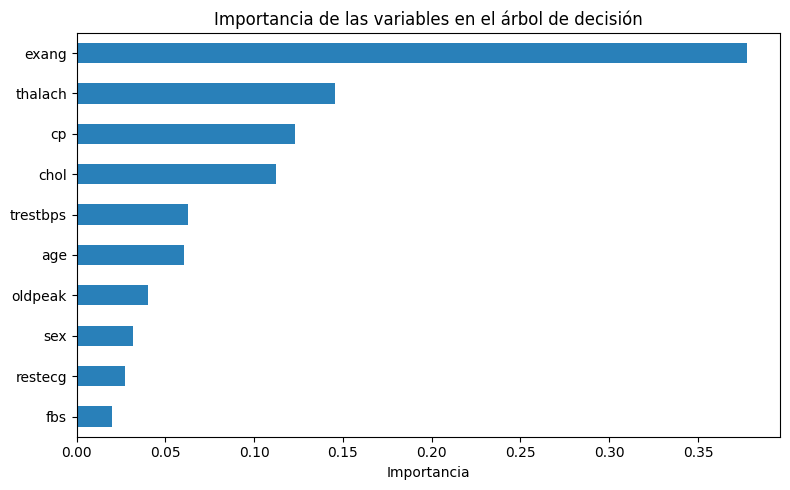

exang       0.377347
thalach     0.145407
cp          0.122718
chol        0.112402
trestbps    0.062525
age         0.060709
oldpeak     0.040373
sex         0.031781
restecg     0.027134
fbs         0.019604
dtype: float64


In [11]:
plt.figure(figsize=(20, 10))
plot_tree(
    modelo,
    feature_names=feature_names,
    class_names=["Sin riesgo", "Con riesgo"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3,  # se muestran solo los primeros 3 niveles para que sea legible
)
plt.title("Árbol de decisión (primeros 3 niveles)")
plt.show()

# Importancia de cada variable en las decisiones del árbol
importancias = pd.Series(modelo.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importancias.plot(kind="barh", color="#2980b9")
plt.title("Importancia de las variables en el árbol de decisión")
plt.xlabel("Importancia")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importancias)


## Bloque 10 — Evaluación de equidad por sexo
Se compara el desempeño del modelo entre pacientes hombres y mujeres, ya que la literatura documenta que los síntomas de infarto en mujeres suelen subdiagnosticarse.

     Grupo   N  Accuracy    Recall
0  Mujeres  11  0.818182  1.000000
1  Hombres  34  0.764706  0.714286


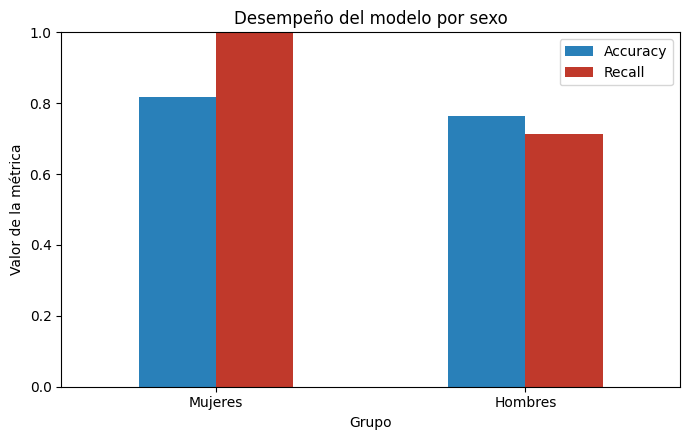

In [12]:
resultados_sexo = []
for valor_sexo, etiqueta in [(0, "Mujeres"), (1, "Hombres")]:
    mask = (X_test["sex"] == valor_sexo)
    if mask.sum() == 0:
        continue
    acc_grupo = accuracy_score(y_test[mask], y_pred[mask])
    rec_grupo = recall_score(y_test[mask], y_pred[mask], zero_division=0)
    resultados_sexo.append({"Grupo": etiqueta, "N": int(mask.sum()), "Accuracy": acc_grupo, "Recall": rec_grupo})

tabla_equidad = pd.DataFrame(resultados_sexo)
print(tabla_equidad)

tabla_equidad.set_index("Grupo")[["Accuracy", "Recall"]].plot(
    kind="bar", figsize=(7, 4.5), color=["#2980b9", "#c0392b"]
)
plt.title("Desempeño del modelo por sexo")
plt.ylabel("Valor de la métrica")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## Bloque 11 — Probar el modelo con un paciente nuevo

In [13]:
# Ejemplo de un paciente nuevo (ajusta los valores según el caso que quieras probar)
paciente_nuevo = pd.DataFrame([{
    "age": 58,
    "sex": 1,
    "cp": 3,
    "trestbps": 145,
    "chol": 260,
    "fbs": 0,
    "restecg": 1,
    "thalach": 140,
    "exang": 1,
    "oldpeak": 2.1,
}])[feature_names]

prediccion = modelo.predict(paciente_nuevo)[0]
probabilidad = modelo.predict_proba(paciente_nuevo)[0][1]

print("Predicción para el paciente nuevo:")
print("Riesgo de infarto:", "SÍ" if prediccion == 1 else "NO")
print(f"Probabilidad estimada: {probabilidad*100:.1f}%")


Predicción para el paciente nuevo:
Riesgo de infarto: SÍ
Probabilidad estimada: 100.0%
